**Problems With Counting Models**

In [131]:
# If we are to take more context into account, the lookup table grows exponentially with the length of the context.
#
#
# 1 characters of context (Bigram), we need 27x27
# 2 characters of context (Bigram), we need 27x27x27
# 3 characters of context (Bigram), we need 27x27x27x27

https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

https://en.wikipedia.org/wiki/Word_embedding

In [132]:
# Training: "The cat is  walking in the bedroom"
# Test:     "A   dog was running in a   room"

# We are out of distribution! Even though a human could understand that these two sentences are syntatically and semantically similar.

We therefore need to create a model that places the embedding for "the" and "a" similar together, and "is" and "was", and "cat" and "dog" and "walking" or "running".

These pairs are semantically similar (they are not equivalent, but generally related in meaning). The model should be able to generalize information it learns about words in its training set to these semantically similar words.

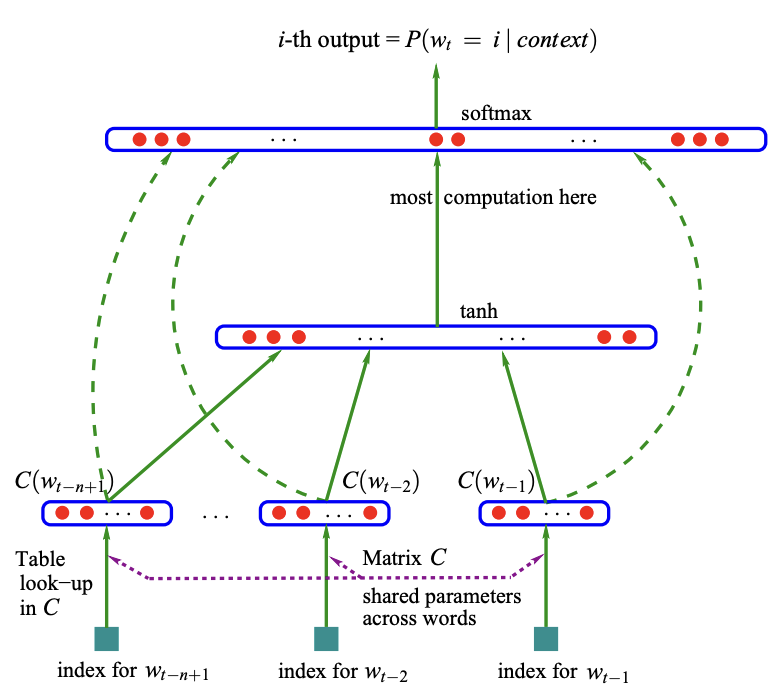

In [133]:
from IPython.display import Image, display
display(Image(filename='/content/model.png' ))

The output dimension of the model has to be 17,000

Remember that the purpose of our soft-max is to take us from "log counts" to actual probabilities. We are basically just thinking in our mind that we are training our model to predict not probabilities, because that's really hard for models to do, but the actual counts themselves. And for mathematical consistency let's try and predict log counts as opposed to counts. This means that when we apply softmax, we end up w probabilities.

**Makemore MLP**

In [134]:
pip install torch

In [135]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [136]:
# read in all the words
words = open('/content/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [137]:
len(words)

32033

In [138]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [139]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [140]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [141]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [142]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

Now let's write the neural network that takes these X's, makes embeddings, and then predicts the Y.

In [143]:
C = torch.randn((27, 2))

In [144]:
C[5]

tensor([-0.7059,  1.5924])

One possible embedding is just a 2 dimensional vector, each character maps to 2D vector. Another is the One Hot Encoding we talked about last time.

In [145]:
# this will error: F.one_hot(5, num_classes=27)

In [146]:
# Must be a tensor not an int
F.one_hot(torch.tensor(5), num_classes=27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [147]:
# this wll error: F.one_hot(torch.tensor(5), num_classes=27) @ C

In [148]:
# Need to keep data types consistent when doing mat mul
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.7059,  1.5924])

Embedding of an integer can either be thought of as indexing into a lookup table C, it can also be thought of as a 1 layer neural network, where the weights are C and the inputs are one hot encoded.

That's how real GPT models do this step, for now we will just keep it as indexing in.

In [149]:
C[5]

tensor([-0.7059,  1.5924])

In [150]:
# PyTorch indexing can grab multiple rows at a time
C[[5,6,7]]

tensor([[-0.7059,  1.5924],
        [-0.6164,  0.3216],
        [ 0.0207,  1.2869]])

In [151]:
C[[5,6,7,7,7]]

tensor([[-0.7059,  1.5924],
        [-0.6164,  0.3216],
        [ 0.0207,  1.2869],
        [ 0.0207,  1.2869],
        [ 0.0207,  1.2869]])

In [152]:
C[torch.tensor([5,6,7,7,7])]

tensor([[-0.7059,  1.5924],
        [-0.6164,  0.3216],
        [ 0.0207,  1.2869],
        [ 0.0207,  1.2869],
        [ 0.0207,  1.2869]])

Ok but remember, our input matrix X has the indices into this word embedding table that we would like. So if each row of X represents 3 characters, and each column a single character in a trigram, then indexing in will return us a 3 dimensional result.

The first axis will be represent for our trigrams, the second dimension is each of the words, and the final dimension stores the actual embeddings.

In [153]:
X.shape

torch.Size([32, 3])

In [154]:
C.shape

torch.Size([27, 2])

In [155]:
C[X].shape

torch.Size([32, 3, 2])

In [156]:
# Let me prove this to you. Let's look at the 13th trigram and the third character
print(X[13,2])
# Now lets get the embedding for that character
print(C[1])

tensor(1)
tensor([0.0862, 1.4134])


In [157]:
# Or we can just index at the front and index for the 13th trigram and third character at the end
print(C[X][13,2])

# It's the same!

tensor([0.0862, 1.4134])


In [158]:
print(C[1])

tensor([0.0862, 1.4134])


So these are our embeddings! We will take a character and store it as a 2D vector.

In [159]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

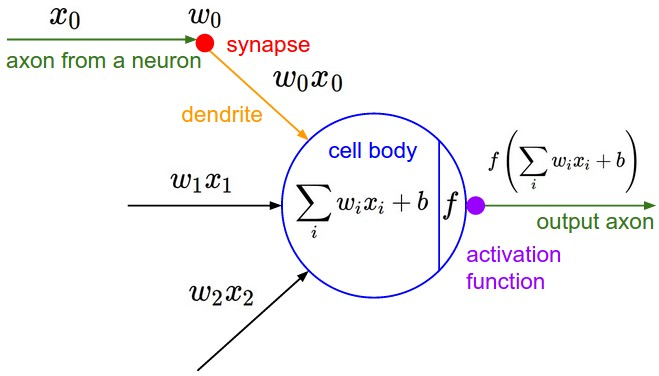

In [160]:
from IPython.display import Image, display
display(Image(filename='/content/cell_body.jpeg' ))

In [161]:
# The inputs to this layer are the 3 characters (a trigram), and each character is
# embeddded as a 2D vector. So 2 * 3 = 6, that's the input dimension.

# The output dimension is arbitrary, its our hidden layer, we can make it up.
# Remember it's saying how many neurons do we want to have. And I want 100 neurons,
# each neuron needs a bias so we include that too.
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [162]:
# This will not work however because emb is shape (32,3,2), we need to turn it into
# (32,6) so the matrix math works.
# this will error: emb @ W1 + b1

.cat can concat these embeddings together

 https://docs.pytorch.org/docs/stable/generated/torch.cat.html

In [163]:
# Let's grab, for all examples, first just the 0th character in the trigram
print(emb[:, 0, :].shape)

# Now for all examples, let's grab the 1st character in the trigram, and the same for the second
print(emb[:, 1, :].shape)
print(emb[:, 2, :].shape)

torch.Size([32, 2])
torch.Size([32, 2])
torch.Size([32, 2])


In [164]:
# Now let's concatenate these together, so it ends up with (32, 6). We need
# to concatenate, not by dimension 0 (that would give us 96 by 2 stacking it vertically)
# we need to concatenate on dimension 1 and stack horizontally
print(torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]]).shape)
concat_emb = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape
print(concat_emb)

torch.Size([96, 2])
torch.Size([32, 6])


In [165]:
# Ok but this is pretty ugly, right now we have 3 words, but what if in the future
# we want to do it for 5 words (pentgrams not trigrams)
# Then we'd do this:

In [166]:
emb5 = torch.randn((32,5,2))
print(
    torch.cat(
        [emb5[:, 0, :],
         emb5[:, 1, :],
         emb5[:, 2, :],
         emb5[:, 3, :],
         emb5[:, 4, :]
        ],
        dim=1,
    ).shape,
)

torch.Size([32, 10])


Thankfully we can use torch.unbind which removes a tensor dimension. https://docs.pytorch.org/docs/stable/generated/torch.unbind.html

In [167]:
# This gives us a list of tuples along a given dimension, so in our case
# it does a tuple of length 3 (that's the 2nd dimension bc we are 32x3x2) and
# in it are tensors that represent the first column, the second column, and third of emb
torch.unbind(emb, 1)

(tensor([[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7059,  1.5924],
         [-1.4656,  0.1912],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-1.3855,  2.5322],
         [-0.3946,  1.5070],
         [-0.0394, -1.3297],
         [ 0.7614, -2.0322],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [ 0.0862,  1.4134],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.0394, -1.3297],
         [ 0.9923, -0.5812],
         [ 0.0862,  1.4134],
         [-1.5794, -0.1153],
         [-0.7059,  1.5924],
         [-0.3946,  1.5070],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [ 0.9923, -0.5812],
         [-1.3855,  2.5322],
         [ 1.2294, -0.1292],
         [-0.1728,  0.4463]]),
 tensor([[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0

In [168]:
torch.cat(torch.unbind(emb, 1), dim=1).shape

torch.Size([32, 6])

In [169]:
# But there's something even simpler we can do!
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [170]:
# Views are how we look at different permutations of dimensions of the same tensor
a.view(2,9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [171]:
a.view(9,2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [172]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [173]:
# View is extremely efficient, because we don't manipulate the data itself.
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [174]:
# View manipulates not the stored data, it doesn't change, copy, move, create,
# but the metadata is changed so its representation is changed.

# storage_offset
# strides
# shapes

https://blog.ezyang.com/2019/05/pytorch-internals/

In [175]:
emb.shape

torch.Size([32, 3, 2])

In [176]:
emb

tensor([[[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383]],

        [[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7059,  1.5924]],

        [[-0.7580,  0.5383],
         [-0.7059,  1.5924],
         [-1.4656,  0.1912]],

        [[-0.7059,  1.5924],
         [-1.4656,  0.1912],
         [-1.4656,  0.1912]],

        [[-1.4656,  0.1912],
         [-1.4656,  0.1912],
         [ 0.0862,  1.4134]],

        [[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-0.7580,  0.5383]],

        [[-0.7580,  0.5383],
         [-0.7580,  0.5383],
         [-1.3855,  2.5322]],

        [[-0.7580,  0.5383],
         [-1.3855,  2.5322],
         [-0.3946,  1.5070]],

        [[-1.3855,  2.5322],
         [-0.3946,  1.5070],
         [-0.0394, -1.3297]],

        [[-0.3946,  1.5070],
         [-0.0394, -1.3297],
         [ 0.7614, -2.0322]],

        [[-0.0394, -1.3297],
         [ 0.7614, -2.0322],
         [-0.0394, -1.3297]],

        [[ 0.7614, -2

In [177]:
emb.view(32,6)

tensor([[-0.7580,  0.5383, -0.7580,  0.5383, -0.7580,  0.5383],
        [-0.7580,  0.5383, -0.7580,  0.5383, -0.7059,  1.5924],
        [-0.7580,  0.5383, -0.7059,  1.5924, -1.4656,  0.1912],
        [-0.7059,  1.5924, -1.4656,  0.1912, -1.4656,  0.1912],
        [-1.4656,  0.1912, -1.4656,  0.1912,  0.0862,  1.4134],
        [-0.7580,  0.5383, -0.7580,  0.5383, -0.7580,  0.5383],
        [-0.7580,  0.5383, -0.7580,  0.5383, -1.3855,  2.5322],
        [-0.7580,  0.5383, -1.3855,  2.5322, -0.3946,  1.5070],
        [-1.3855,  2.5322, -0.3946,  1.5070, -0.0394, -1.3297],
        [-0.3946,  1.5070, -0.0394, -1.3297,  0.7614, -2.0322],
        [-0.0394, -1.3297,  0.7614, -2.0322, -0.0394, -1.3297],
        [ 0.7614, -2.0322, -0.0394, -1.3297,  0.0862,  1.4134],
        [-0.7580,  0.5383, -0.7580,  0.5383, -0.7580,  0.5383],
        [-0.7580,  0.5383, -0.7580,  0.5383,  0.0862,  1.4134],
        [-0.7580,  0.5383,  0.0862,  1.4134,  0.7614, -2.0322],
        [ 0.0862,  1.4134,  0.7614, -2.0

In [178]:
# We can verify its the same with an element wise equal
torch.cat(torch.unbind(emb, 1), dim=1) == emb.view(32,6)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [179]:
# Now we get the activations after our first layer
h = emb.view(32,6) @ W1 + b1

In [180]:
# Let's not hardcode anything to leave this general
h = emb.view(emb.shape[0], 6) @ W1 + b1

In [181]:
# PyTorch is so smart that it can just infer by process of elimination when you leave
# just one dimension blank
h = emb.view(-1, 6) @ W1 + b1

So we figured out how to make our first layer more efficient, previously torch.cat()
would create new memory, now we are reusing our same input vectors and only at
inference time are we just changing up metadata that changes how the matrix multiplication
gets calculated.

In [182]:
# Glossed over one thing.
print((emb.view(-1, 6) @ W1).shape)
print(b1.shape)

torch.Size([32, 100])
torch.Size([100])


In [183]:
# Remember our broadcasting semantics
# Line up the dimensions right wise.

# 32x100 vector needs to be added to 1x100 so we need to broadcast.

# 32, 100
#  1, 100

# 100 and 100 match
# 1 and 32 don't match, but because its a 1 we copy 32 times to match the other vector
# so b1 becomes 32,100 (vertical copies) (you can think of it as torch.cat(b1,b1,b1,...))

# 32, 100
# 32, 100

# aaand we're good!

In [184]:
h.shape

torch.Size([32, 100])

In [185]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [186]:
logits = h @ W2 + b2

In [187]:
logits.shape

torch.Size([32, 27])

In [188]:
# Perfect we have the log-counts for each next character we are trying to predict.
# How do we turn this into a probability? Softmax.
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [189]:
# Now each row has the probabilities of what character is most likely to come next.
prob[0].sum()

tensor(1.)

In [190]:
# Now we need to compare to our ground truth, our Y, and generate a loss, that way
# we can do gradient descent and minimize our loss.
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [191]:
# For each row, grab the column that is 'correct'. One more time, this tensor is
# the tensor of probabilities that our model predicted for each trigram, specifically
# the probability of the character that was actually seen.
prob[torch.arange(32), Y]

tensor([8.0856e-27, 6.0868e-41, 0.0000e+00, 1.0248e-07, 0.0000e+00, 1.4164e-26,
        1.6025e-35, 0.0000e+00, 0.0000e+00, 1.2087e-10, 6.5666e-31, 4.9323e-31,
        8.3002e-11, 1.5105e-40, 1.8081e-03, 2.1586e-28, 1.2650e-31, 2.3918e-27,
        3.4181e-18, 1.9194e-26, 1.1577e-25, 6.3559e-29, 0.0000e+00, 9.6377e-20,
        1.0615e-22, 1.5001e-34, 3.2419e-09, 5.6378e-14, 0.0000e+00, 1.0621e-25,
        1.1027e-05, 3.5879e-19])

In [192]:
# For most charcters this is terrible. It thinks most of the trigrams, that actually exist
# in our dataset are extremely unlikely. Ideally these probabilities are all 1

In [193]:
# For each probability, we get the log likelihood, the negative log likelihood, and
# then average it, and that's our loss.
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(inf)

In [194]:
# Let's get the loss to 0!

Cleaned Up Two Layer NN Code

In [195]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [196]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [197]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [198]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

In [199]:
# Let's make this even more cleaned up.
F.cross_entropy(logits, Y)

tensor(17.7697)

In [200]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# Now we use fused kernels that are way more efficient and don't make
# all these intermediary vectors. The backwards pass also has its own
# kernel that is simplified.
# Remember how for tanh instead of making a GIANT compute graph, we
# just simplified it to 1 expression.
loss = F.cross_entropy(logits, Y)
loss

tensor(17.7697)

In [201]:
# This is the tanh function from out autograd library
#  def tanh(self):
#    x = self.data
#    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
#    out = Value(t, (self, ), 'tanh')
#
#    def _backward():
#      self.grad += (1 - t**2) * out.grad
#    out._backward = _backward
#
#    return out

In [202]:
# Its also more numerically stable. Right now all is well and good.
logits = torch.tensor([-2,3,0,5])
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([7.9781e-04, 1.1841e-01, 5.8950e-03, 8.7490e-01])

In [203]:
# But let's make some of the numbers very negative. Still good.
logits = torch.tensor([-100,3,0,5])
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([0.0000, 0.1185, 0.0059, 0.8756])

In [204]:
# But let's make some of the numbers very positive. Now we explode.
logits = torch.tensor([2,3,0,100])
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([0., 0., 0., nan])

In [205]:
# You can see e^100 overflows, while e^-100 is just basically 0
# When we overflow, we run out of range in our floats and we go to inf
counts

tensor([ 7.3891, 20.0855,  1.0000,     inf])

In [206]:
# The fix that PyTorch implements is an offset. If I take the same code above and just
# offset everything, we are good
logits = torch.tensor([2,3,0,100])
logits -= logits.max()
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([2.7465e-43, 7.4689e-43, 3.7835e-44, 1.0000e+00])

1. Forward pass efficiency
2. Backwards pass efficiency
3. Numerical stability

Reasons to use F.cross_entropy() and not implement it yourself.

**Now let's train the model!**

In [207]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [208]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [209]:
for p in parameters:
    p.requires_grad = True

In [210]:
# forward pass
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
# backward pass
for p in parameters:
    p.grad = None
loss.backward()
# update
for p in parameters:
    lr = 0.1
    p.data += -lr * p.grad
print(loss.item())

17.76971435546875


In [211]:
# Let's do the same cell above but like 10 times:
for _ in range(1000):
    # forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        lr = 0.1
        p.data += -lr * p.grad

13.656401634216309
11.298768997192383
9.452455520629883
7.984262466430664
6.891321182250977
6.100014686584473
5.452036380767822
4.898151874542236
4.414664268493652
3.985848903656006
3.6028308868408203
3.2621419429779053
2.961381196975708
2.6982977390289307
2.469712972640991
2.271660327911377
2.101283550262451
1.9571774005889893
1.8374857902526855
1.7380965948104858
1.6535115242004395
1.579089879989624
1.5117665529251099
1.4496047496795654
1.3913120031356812
1.335992455482483
1.283052921295166
1.2321909666061401
1.18338143825531
1.1367990970611572
1.092664122581482
1.0510923862457275
1.0120267868041992
0.9752704501152039
0.9405565857887268
0.9076125025749207
0.8761921525001526
0.8460890650749207
0.817135751247406
0.7891992330551147
0.7621746063232422
0.7359814047813416
0.7105579972267151
0.6858609318733215
0.6618651747703552
0.6385656595230103
0.6159818172454834
0.5941657423973083
0.5732105374336243
0.553256094455719
0.5344880819320679
0.5171167254447937
0.5013312697410583
0.48724257946

In [212]:
logits.max(1)

torch.return_types.max(
values=tensor([13.3355, 17.7922, 20.6021, 20.6130, 16.7367, 13.3355, 15.9996, 14.1733,
        15.9157, 18.3627, 15.9409, 20.9277, 13.3355, 17.1103, 17.1332, 20.0614,
        13.3355, 16.5901, 15.1031, 17.0594, 18.5873, 15.9684, 10.8751, 10.6882,
        15.5064, 13.3355, 16.1804, 16.9754, 12.7435, 16.2016, 19.0860, 16.0211],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [213]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [214]:
# You can see the indices that we are predicting are right for some of them,
# but we are struggling to fit something meaningful with the little data that we have.

# Look at ...

emma
... ---> e

olivia
... ---> o

ava
... ---> a

isabella
... ---> i

sophia
... ---> s

Our model has no idea what to do! We need more data, ow its just uniform distribution over these 5 chars.

**Full Dataset**

In [215]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

Streaming output truncated to the last 5000 lines.
doron
dovi
draysen
dredyn
dugan
durell
ebin
edwardo
efrem
ehaan
ehab
eirik
eldar
eliav
eligio
eloi
eluzer
elway
emaad
emeka
enki
ero
erron
esaiah
estiven
eulalio
everet
everly
evert
evian
eyas
ezer
ezren
faaris
facundo
famous
farzan
felton
field
filipe
finbar
finch
flynt
fordham
fouad
gabryel
garnet
gaurik
gavi
geovonni
germany
gerrard
gevorg
giuliani
graden
gradyn
grayer
grayton
greylen
grimm
gurshaan
hameed
hanzel
hasib
haylen
henning
herminio
hill
hiyan
hrihaan
huxson
hykeem
ihsaan
imer
imir
iremide
isahi
isaih
ishak
ishank
issachar
issam
issiah
iyaan
izai
izick
jabbar
jabri
jaccob
jadarrius
jadin
jaecion
jaelin
jaelon
jaevon
jah
jahcere
jahmeer
jahvon
jahzir
jaidin
jaishawn
jakaree
jakorey
jalan
jameis
jansiel
janthony
janziel
jarom
jaseer
jaston
jatavion
jathniel
javarius
jawuan
jaxel
jaxxyn
jaxzon
jayace
jaydien
jayke
jaymere
jayniel
jayonni
jayston
jayziah
jazen
jazion
jeramie
jeramyah
jerek
jeremey
jeren
jeric
jerman
jermani
je

In [216]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [217]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [218]:
for _ in range(10):
    # forward pass
    emb = C[X] # (228146, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (228146, 100)
    logits = h @ W2 + b2 # (228146, 27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        lr = 0.1
        p.data += -lr * p.grad

19.505226135253906
17.08449363708496
15.776531219482422
14.833340644836426
14.002603530883789
13.253260612487793
12.57991886138916
11.983101844787598
11.47049331665039
11.051856994628906


In [219]:
# You can see how slow this is! It's because we are forwarding and backwarding on all 228k entries
# at a time. So basically thats why we do mini-batching where we only go at a subset of
# the data at a time

In [220]:
torch.randint(0, X.shape[0], (32,))

# See we get 32 random row indices.

tensor([  2525, 195532, 186941,  56464, 133176,  43285,   6533, 163749,  17330,
        215202,   9583, 143345, 222542,   3770,  68065, 192282, 122335,   9934,
         37600, 183687, 115562,   5081, 151324,  13256,  99498,  91936,  31157,
        199670, 197209,  66747,  12141, 178510])

**Mini Batching**

In [221]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [222]:
for _ in range(10):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        lr = 0.1
        p.data += -lr * p.grad

17.127445220947266
19.244544982910156
19.35736846923828
14.591804504394531
14.884354591369629
12.1633939743042
11.759520530700684
13.825854301452637
9.104748725891113
9.687458038330078


In [223]:
# This is much faster, now we can up it to 1000 no problem
for _ in range(1000):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        lr = 0.1
        p.data += -lr * p.grad

print(loss.item())

2.743307590484619


In [224]:
# We are trading off the quality of our gradient with the # of steps we are able to achieve.

In [225]:
# This is just the loss for the minibatch, I need to do a forward pass on everything to get
# the loss for the total training set.# forward pass
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
print(loss)

tensor(2.7310, grad_fn=<NllLossBackward0>)


Hovering just above 2.5. We need to pick a better learning rate.

In [226]:
# Let's try 6 different learning rates
lrs = [10, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
lr_losses = []
for lr in lrs:
    # Have to reset everything lmao
    g = torch.Generator().manual_seed(2147483647) # for reproducibility
    C = torch.randn((27, 2), generator=g)
    W1 = torch.randn((6, 100), generator=g)
    b1 = torch.randn(100, generator=g)
    W2 = torch.randn((100, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    parameters = [C, W1, b1, W2, b2]

    for p in parameters:
        p.requires_grad = True

    for _ in range(1000):
        # minibatch
        ix = torch.randint(0, X.shape[0], (32,))
        # forward pass
        emb = C[X[ix]] # (32, 3, 2)
        h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
        logits = h @ W2 + b2 # (32, 27)
        loss = F.cross_entropy(logits, Y[ix])
        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()
        # update
        for p in parameters:
            p.data += -lr * p.grad
    lr_losses.append(loss.item())

for i in range(len(lrs)):
    print(str(lrs[i]) + ": " + str(lr_losses[i]))

10: 49.55659484863281
1: 6.026280403137207
0.5: 2.729238748550415
0.1: 2.6557137966156006
0.05: 2.598569869995117
0.01: 4.350064277648926
0.005: 4.69533109664917
0.001: 10.179945945739746


In [227]:
# There's a better way of doing this

In [228]:
# Have to reset everything lmao
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [229]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [230]:
lri = []
lossi = []

for i in range(1000):

  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

#print(loss.item())

17.69206428527832
22.617259979248047
20.56943130493164
17.212617874145508
21.272390365600586
18.130516052246094
19.267284393310547
17.947269439697266
18.440317153930664
17.82073402404785
18.61637306213379
18.74093246459961
18.561904907226562
21.336942672729492
20.521791458129883
16.67331314086914
19.140880584716797
20.849754333496094
19.661441802978516
16.769607543945312
15.689446449279785
17.296422958374023
17.948741912841797
20.195302963256836
18.533918380737305
19.712926864624023
17.172792434692383
20.428552627563477
19.771638870239258
18.87480926513672
19.268470764160156
20.091068267822266
16.40393829345703
16.933351516723633
20.230772018432617
17.383586883544922
18.291088104248047
18.639028549194336
18.364574432373047
16.175556182861328
18.197681427001953
15.864587783813477
16.295644760131836
17.295063018798828
16.98963165283203
15.538861274719238
17.62120246887207
18.269338607788086
18.34653091430664
19.451684951782227
16.69269371032715
19.42396354675293
16.589731216430664
17.049

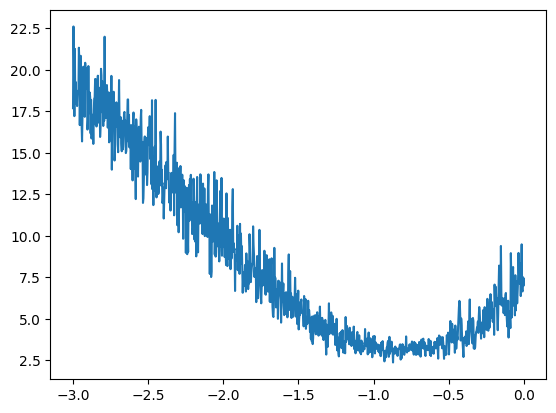

In [231]:
plt.plot(lri, lossi)

In [232]:
# So a good exponent of the learning rate is -1.0

In [233]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

stepi = []
lossi = []

for i in range(20000):
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item())

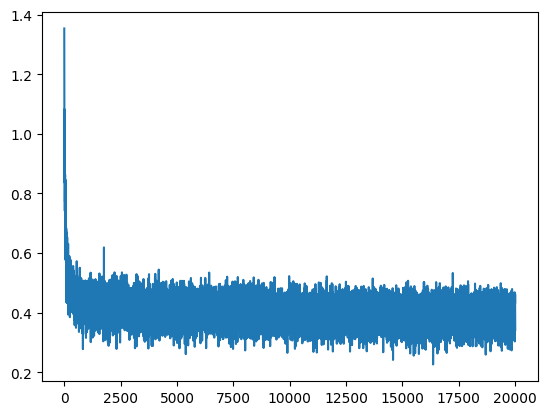

In [234]:
plt.plot(stepi, lossi)

In [235]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss.item()

2.4429922103881836

In [236]:
# What's actually done in production is that we taper the learning rate.
# So initially we train on a decent sized LR, and then taper it off
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

stepi = []
lossi = []

for i in range(20000):
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item()) # show students without log10 first/

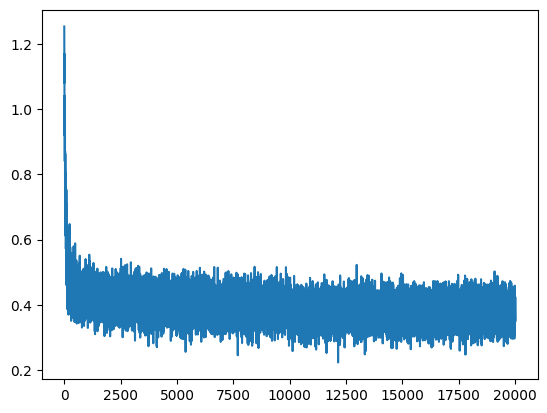

In [237]:
plt.plot(stepi, lossi)

In [238]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss.item()

2.395951271057129

**Training, Validation, & Test Split**

In [239]:
# training split, dev/validation split, test split.
# We should only ever test the loss on the test set, other wise we are over fitting to
# the test data.
# 80%, 10%, 10%

In [240]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [241]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

for i in range(30000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

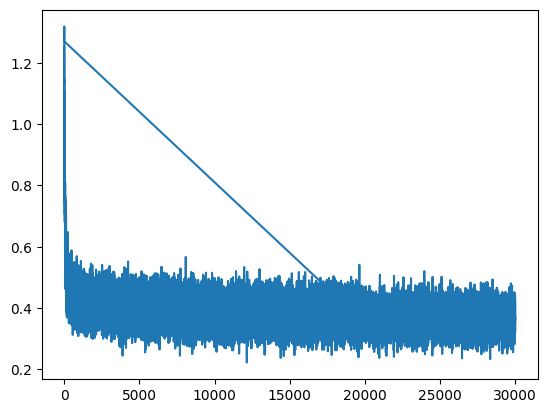

In [242]:
plt.plot(stepi, lossi)

In [243]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
trloss = F.cross_entropy(logits, Ytr)
print("TRAINING LOSS: ", trloss.item())

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
devloss = F.cross_entropy(logits, Ydev)
print("DEV LOSS: ", devloss.item())

TRAINING LOSS:  2.3578217029571533
DEV LOSS:  2.3537118434906006


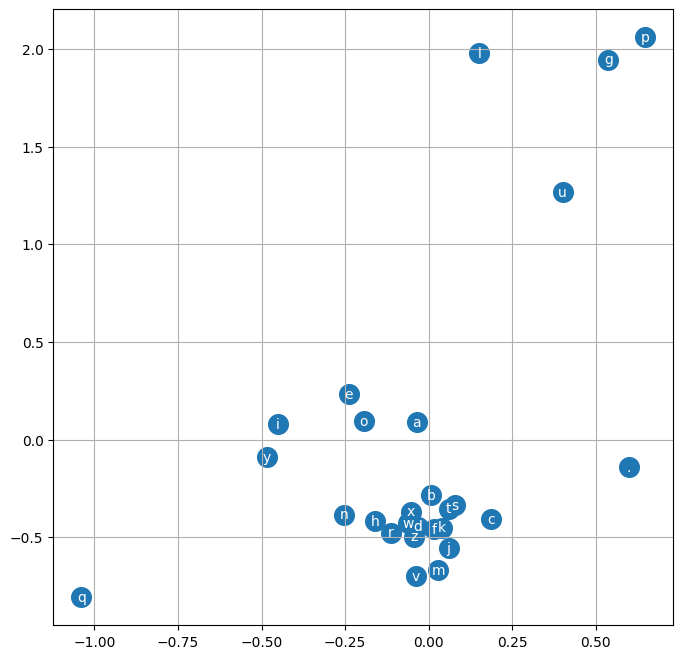

In [244]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [245]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carelixa.
jelle.
hiwmili.
thty.
hacansie.
rahnen.
dperrit.
kaqui.
nellara.
chaiiv.
kaleig.
dham.
join.
quinn.
sroilea.
jadbi.
wazero.
dearyxi.
jacenniluat.
edde.


**Let's Increase The Size of The Model**

We are not overfitting, the proof is that training loss and dev loss is about the same.

In [246]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [247]:
HIDDEN_LAYER_SIZE = 300

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, HIDDEN_LAYER_SIZE), generator=g)
b1 = torch.randn(HIDDEN_LAYER_SIZE, generator=g)
W2 = torch.randn((HIDDEN_LAYER_SIZE, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

for i in range(60000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

In [248]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
trloss = F.cross_entropy(logits, Ytr)
print("TRAINING LOSS: ", trloss.item())

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
devloss = F.cross_entropy(logits, Ydev)
print("DEV LOSS: ", devloss.item())

TRAINING LOSS:  2.307901382446289
DEV LOSS:  2.314485549926758


In [249]:
# Batch size is too low, so we are thrashing too much
# Training time was too low because we have more parameters
# Another issue is our embedding dimension is only 2

In [250]:
HIDDEN_LAYER_SIZE = 300
VOCAB_DIMENSION = 10

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, VOCAB_DIMENSION), generator=g)
W1 = torch.randn((VOCAB_DIMENSION * 3, HIDDEN_LAYER_SIZE), generator=g)
b1 = torch.randn(HIDDEN_LAYER_SIZE, generator=g)
W2 = torch.randn((HIDDEN_LAYER_SIZE, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

for i in range(60000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, VOCAB_DIMENSION * 3) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

In [251]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, VOCAB_DIMENSION * 3) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
trloss = F.cross_entropy(logits, Ytr)
print("TRAINING LOSS: ", trloss.item())

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, VOCAB_DIMENSION * 3) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
devloss = F.cross_entropy(logits, Ydev)
print("DEV LOSS: ", devloss.item())

TRAINING LOSS:  2.2513134479522705
DEV LOSS:  2.277214765548706


In [252]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

careah.
amelle.
khi.
mre.
rehty.
salana.
emmahnen.
deliah.
tireei.
nelynn.
tceniah.
kaleig.
dham.
pore.
quinn.
shon.
talian.
quinathon.
jaryxik.
kaedid.
